In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
#from sklearn.datasets.samples_generator import make_blobs
from sklearn.datasets import make_blobs

C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


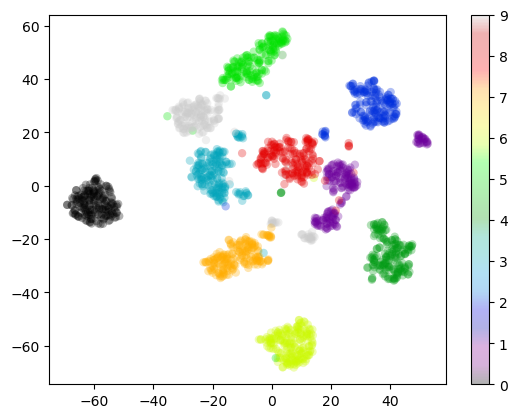

In [2]:
from sklearn import datasets
digits = datasets.load_digits()

X = digits.data
y = digits.target

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2,learning_rate=200)
X_reduced = tsne.fit_transform(X)

plt.scatter(X_reduced[:,0],X_reduced[:,1], 
            c=y, cmap="nipy_spectral", alpha=0.3, 
            edgecolor="None")
plt.colorbar()

In [3]:
from sklearn.cluster import MeanShift
from sklearn.cluster import KMeans
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()

bandwidth =   0.44
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform(X_reduced))

labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])

In [4]:
# Set a n_clusters KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=0)

# Compute cluster centers and predict cluster indices
X_clustered = kmeans.fit_predict(X_reduced)

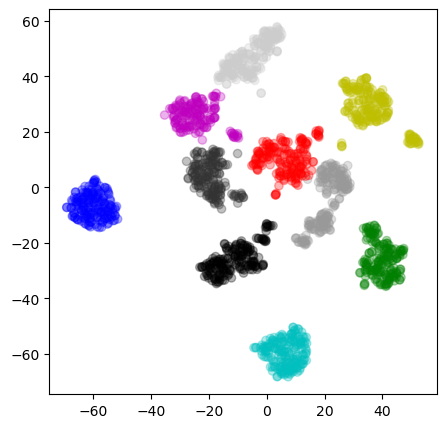

In [5]:
#plotting the result
LABEL_COLOR_MAP = {0 : 'r',
                   1 : 'g',
                   2 : 'b',
                   3 : 'c',
                   4 : 'm',
                   5 : 'y',
                   6 : '0',
                   7 : '0.8',
                   8 : '0.6',
                   9 : '0.2'}

label_color = [LABEL_COLOR_MAP[l] for l in X_clustered]
plt.figure(figsize = (5,5))
plt.scatter(X_reduced[:,0],X_reduced[:,1], c= label_color, alpha=0.3)
plt.show()